# KAKM — Kerzz Akıllı Karlılık Motoru

**Demo Notebook**

Bu notebook, KAKM'nin analitik çekirdeğini hücre hücre gezdirir. Her modül kendi başına çalışır; sırayla okuyabilir veya doğrudan ilgilendiğiniz bölüme atlayabilirsiniz.

**İçindekiler:**

1. Veri keşfi — POS verisinin temel istatistikleri
2. Modül 1: Menü Mühendisliği Matrisi
3. Modül 2: COGS Anomali Tespiti (Isolation Forest)
4. Modül 3: Nakit Akışı Tahmini (Monte Carlo)
5. Modül 4: Finansal Sağlık Skoru
6. Şube karşılaştırması — tüm zincir tek bakışta

**Önkoşul:** `python generate_synthetic_data.py` çalıştırılmış olmalı.

In [29]:

import pandas as pd
import matplotlib.pyplot as plt

import data_loader as dl
import menu_engineering as me
import cogs_anomaly as ca
import cash_flow_forecast as cf
import health_score as hs


plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("Modüller yüklendi.")

Modüller yüklendi.


## 1. Veri Keşfi

Önce elimizdeki POS verisine bakalım — 7 şube, 23 ürün, son 120 günlük satış kayıtları.

In [30]:

dl.subeler()

,id,isim,bolge,acilis_tarihi
0,1,Kadıköy Merkez,İstanbul Anadolu,2019-03-15
1,2,Bağdat Caddesi,İstanbul Anadolu,2020-09-01
2,3,Nişantaşı,İstanbul Avrupa,2018-06-20
3,4,Beşiktaş,İstanbul Avrupa,2021-02-10
4,5,Ataşehir,İstanbul Anadolu,2022-05-05
5,6,Bakırköy,İstanbul Avrupa,2021-11-12
6,7,Maslak,İstanbul Avrupa,2023-01-20


In [31]:

dl.urunler().sort_values("kar_marji", ascending=False).head(10)

,id,isim,kategori,satis_fiyati,maliyet,birim_kar,kar_marji
15,16,Çay,İçecek,25.0,4.0,21.0,0.840000
17,18,Su,İçecek,15.0,3.0,12.0,0.800000
18,19,Asya Çayı,İçecek,35.0,8.0,27.0,0.771429
19,20,Maden Suyu,İçecek,25.0,6.0,19.0,0.760000
16,17,Türk Kahvesi,İçecek,45.0,12.0,33.0,0.733333
11,12,Spring Roll,Başlangıç,75.0,22.0,53.0,0.706667
13,14,Edamame,Başlangıç,55.0,18.0,37.0,0.672727
20,21,Mochi Ice Cream,Tatlı,85.0,28.0,57.0,0.670588
0,1,Pad Thai,Ana Yemek,185.0,62.0,123.0,0.664865
21,22,Cheesecake,Tatlı,95.0,32.0,63.0,0.663158


In [32]:

satis = dl.satislar(sube_id=1, gun=30)
print(f"Toplam satış kaydı: {len(satis):,}")
print(f"Toplam ciro:        ₺{satis['ciro'].sum():,.0f}")
print(f"Toplam kar:         ₺{satis['kar'].sum():,.0f}")
print(f"Tarih aralığı:      {satis['tarih'].min().date()} — {satis['tarih'].max().date()}")
satis.head()

Toplam satış kaydı: 689
Toplam ciro:        ₺1,096,145
Toplam kar:         ₺695,165
Tarih aralığı:      2026-04-27 — 2026-05-26


,tarih,sube_id,urun_id,satilan_miktar,urun,kategori,satis_fiyati,maliyet,birim_kar,ciro,kar
0,2026-04-27,1,1,15,Pad Thai,Ana Yemek,185.0,62.0,123.0,2775.0,1845.0
1,2026-04-27,1,2,11,Tavuk Curry,Ana Yemek,195.0,71.0,124.0,2145.0,1364.0
2,2026-04-27,1,3,10,Beef Noodle,Ana Yemek,220.0,95.0,125.0,2200.0,1250.0
3,2026-04-27,1,4,11,Crispy Duck,Ana Yemek,285.0,124.0,161.0,3135.0,1771.0
4,2026-04-27,1,5,11,Karides Wok,Ana Yemek,245.0,102.0,143.0,2695.0,1573.0


## 2. Modül 1 — Menü Mühendisliği Matrisi

Her ürünü popülerlik × katkı marjı eksenlerinde 4 kadrana ayırır:

- **Şampiyon** (yüksek satış + yüksek marj): koru, görünür tut
- **Lokomotif** (yüksek satış + düşük marj): maliyet pazarlığı
- **Gizli Cevher** (düşük satış + yüksek marj): tanıt, garsona ver
- **Zayıf Halka** (düşük satış + düşük marj): menüden çıkar

Eşik olarak medyan kullanılır — ortalama uç değerlerden bozulur.

In [33]:

menu_df = me.analiz_et(sube_id=1, gun=90)

print("Sınıf dağılımı:")
print(menu_df["siniflandirma"].value_counts())
print()
print("Öne çıkan aksiyon:")
print(" →", me.one_cikan_aksiyon(menu_df))

Sınıf dağılımı:
siniflandirma
Gizli Cevher    7
Lokomotif       7
Şampiyon        5
Zayıf Halka     4
Name: count, dtype: int64

Öne çıkan aksiyon:
 → 'Mantar Risotto' son 90 günde sadece 153 kez satıldı, marj %19. Menüden çıkarmayı değerlendir.


In [34]:

menu_df[["urun", "kategori", "toplam_satis", "birim_kar", "kar_marji_yuzde", "toplam_kar", "siniflandirma"]]

,urun,kategori,toplam_satis,birim_kar,kar_marji_yuzde,toplam_kar,siniflandirma
0,Pad Thai,Ana Yemek,1758,123.0,66.5,216234.0,Şampiyon
1,Tavuk Curry,Ana Yemek,1536,124.0,63.6,190464.0,Şampiyon
2,Karides Wok,Ana Yemek,1232,143.0,58.4,176176.0,Gizli Cevher
3,Beef Noodle,Ana Yemek,1386,125.0,56.8,173250.0,Şampiyon
4,Crispy Duck,Ana Yemek,951,161.0,56.5,153111.0,Gizli Cevher
5,Spring Roll,Başlangıç,2836,53.0,70.7,150308.0,Lokomotif
6,Dim Sum,Başlangıç,2172,57.0,60.0,123804.0,Şampiyon
7,Türk Kahvesi,İçecek,3495,33.0,73.3,115335.0,Lokomotif
8,Çay,İçecek,4450,21.0,84.0,93450.0,Lokomotif
9,Cheesecake,Tatlı,1375,63.0,66.3,86625.0,Gizli Cevher


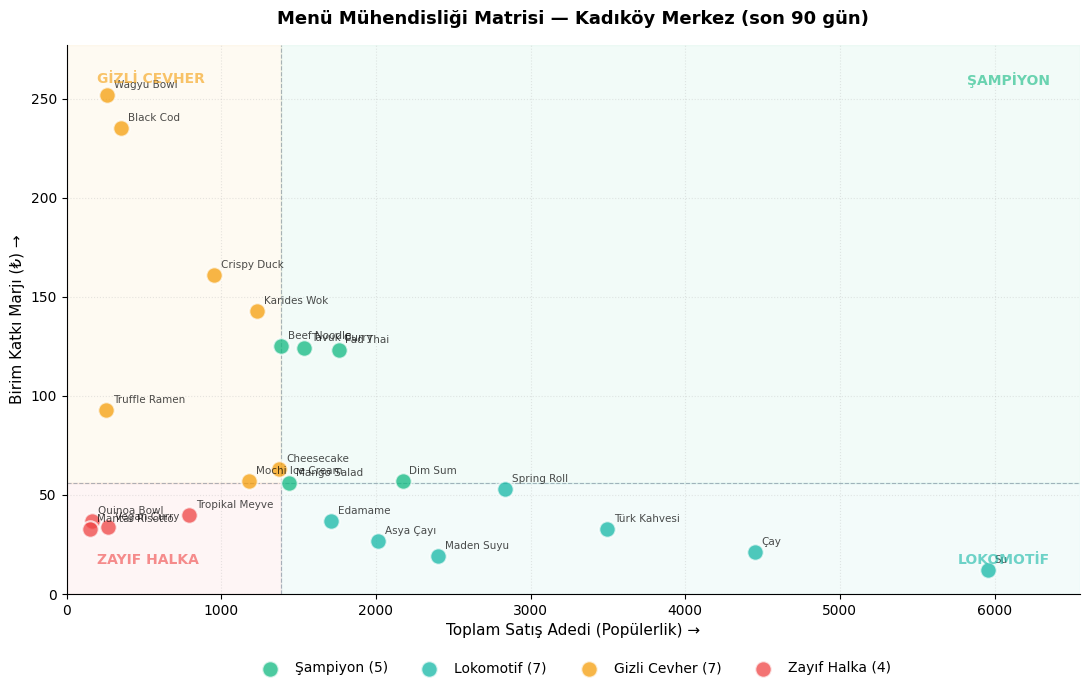

In [35]:

fig = me.ciz(menu_df)
plt.show()

## 3. Modül 2 — COGS Anomali Tespiti

Restoran finansının en sessiz sızıntısı: **teorik tüketim** ile **gerçek tüketim** arasındaki açık.

İki yaklaşım birlikte kullanılıyor:

1. **Eşik bazlı:** %5'in üstünde sapma bayrak. Basit ve hızlı.
2. **Isolation Forest:** Bağlamsal anomaliler. "Cuma akşamı her ürün %3 sapma yapar ama bu Cuma Beef Noodle %12 sapma yaptı" gibi desen bozulmalarını yakalar.

In [36]:
# Eşik bazlı anomali tespiti (son 7 gün)
esik_anom = ca.esik_bazli_anomaliler(sube_id=1, gun=7, esik_yuzde=5.0)
print(f"Son 7 günde {len(esik_anom)} eşik üstü anomali bulundu.")
print(f"Toplam tahmini kayıp: ₺{esik_anom['sapma_tl'].sum():,.0f}")
esik_anom

Son 7 günde 9 eşik üstü anomali bulundu.
Toplam tahmini kayıp: ₺2,360


,urun_id,urun,kategori,teorik,gercek,sapma_tl,sapma_yuzde,seviye
0,3,Beef Noodle,Ana Yemek,10260.0,10854.01,594.01,5.79,orta
1,4,Crispy Duck,Ana Yemek,9796.0,10374.88,578.88,5.91,orta
2,5,Karides Wok,Ana Yemek,10812.0,11369.34,557.34,5.15,orta
3,17,Türk Kahvesi,İçecek,3444.0,3618.73,174.73,5.07,orta
4,13,Mango Salad,Başlangıç,3016.0,3167.78,151.78,5.03,orta
5,6,Mantar Risotto,Ana Yemek,1988.0,2090.04,102.04,5.13,orta
6,23,Tropikal Meyve,Tatlı,1625.0,1707.13,82.13,5.05,orta
7,16,Çay,İçecek,1432.0,1508.73,76.73,5.36,orta
8,15,Truffle Ramen,Başlangıç,832.0,874.71,42.71,5.13,orta


In [37]:
# Isolation Forest ile bağlamsal anomaliler (son 30 gün, top 10)
ml_anom = ca.isolation_forest_anomaliler(sube_id=1, gun=30)
print(f"Toplam {len(ml_anom)} anomali tespit edildi.")
print("\nEn yüksek skorlu 10 anomali:")
ml_anom.head(10)

Toplam 35 anomali tespit edildi.

En yüksek skorlu 10 anomali:


,tarih,urun,kategori,teorik_tuketim,gercek_tuketim,sapma,sapma_yuzde,gun_adi,anomali_skoru
0,2026-05-22,Crispy Duck,Ana Yemek,1488.0,1680.49,192.49,12.94,4,0.719827
1,2026-05-01,Crispy Duck,Ana Yemek,1488.0,1674.84,186.84,12.56,4,0.713041
2,2026-05-08,Crispy Duck,Ana Yemek,1488.0,1663.88,175.88,11.82,4,0.692595
3,2026-05-15,Crispy Duck,Ana Yemek,1488.0,1662.03,174.03,11.70,4,0.691658
4,2026-05-22,Beef Noodle,Ana Yemek,1425.0,1594.75,169.75,11.91,4,0.689255
5,2026-05-01,Beef Noodle,Ana Yemek,1235.0,1381.39,146.39,11.85,4,0.688789
6,2026-05-08,Beef Noodle,Ana Yemek,1805.0,2008.00,203.00,11.25,4,0.685603
7,2026-05-15,Beef Noodle,Ana Yemek,1045.0,1155.08,110.08,10.53,4,0.677304
8,2026-05-17,Tropikal Meyve,Tatlı,350.0,373.46,23.46,6.70,6,0.661435
9,2026-05-10,Pad Thai,Ana Yemek,1054.0,1121.89,67.89,6.44,6,0.658221


💡 **Dikkat:** En yüksek skorlu anomalilerin hepsi Cuma günleri ve hep Beef Noodle / Crispy Duck'ta. Bu sentetik veride bilinçli eklenmiş bir desen — gerçek senaryoda bu Cuma akşamı kasiyer/şef değişimini veya tedarik kaynaklı düzensizliği işaret eder.

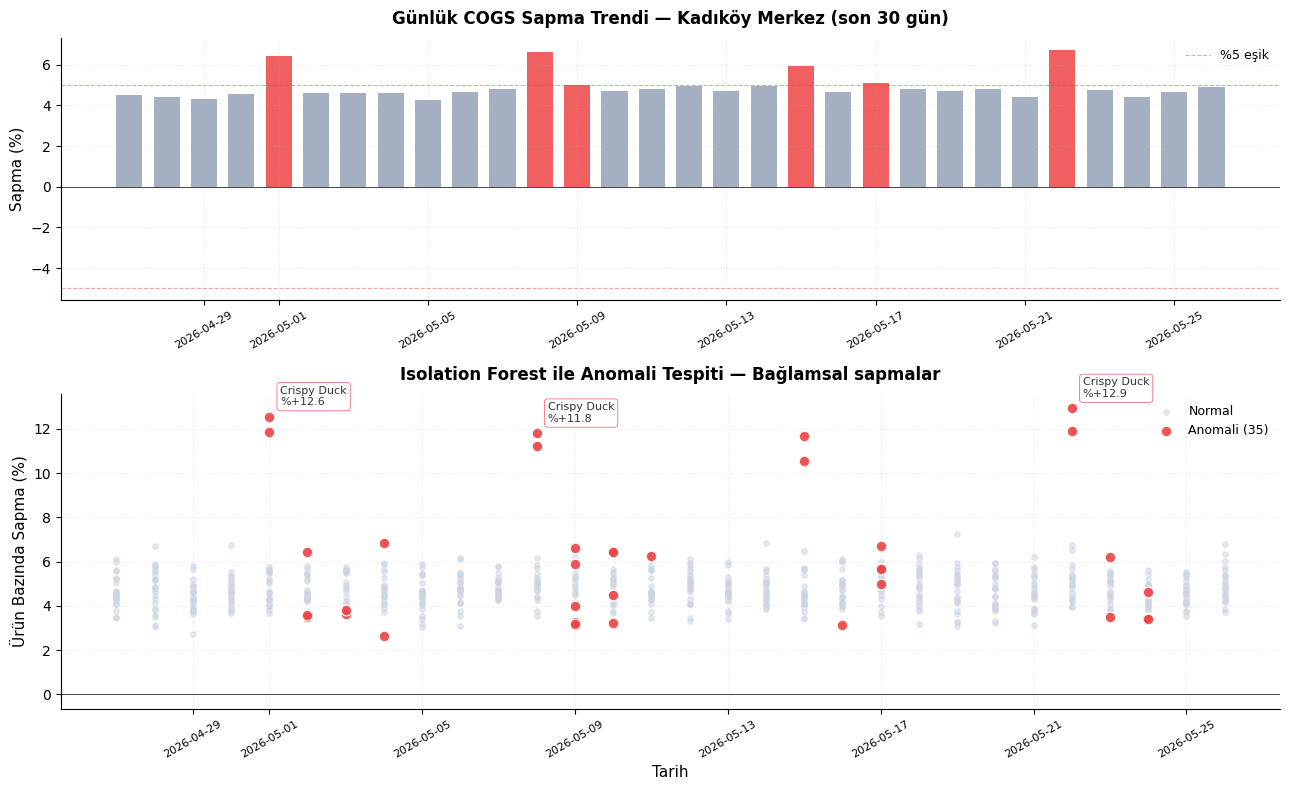

In [38]:
# Görselleştirme — günlük trend + ürün bazında anomali noktaları
fig = ca.ciz(sube_id=1, gun=30)
plt.show()

## 4. Modül 3 — Nakit Akışı Tahmini

Restoranın en büyük finansal kabusu: kasanın yanlış zamanda boşalması.

**Yöntem:** Son 60 günlük günlük ciro serisinden haftalık desen çıkar, 1000 Monte Carlo senaryosu üret, her gün için P10/P50/P90 yüzdelikleri hesapla. Yaklaşan giderler (maaş, kira, vergi) hesaba katılır.

Tek nokta tahmin yerine **güven aralığı** sunulur — kötü senaryo gizlenmez.

In [39]:
# Kadıköy — sağlıklı durum
tahmin_kdky = cf.tahmin_et(sube_id=1, gun_sayisi=14)
print("Kadıköy 14 günlük nakit akışı:")
uyari = cf.risk_uyarisi(tahmin_kdky)
print(uyari or "  ✓ Risk yok")
tahmin_kdky

Kadıköy 14 günlük nakit akışı:
  ✓ Risk yok


,tarih,p10,p50,p90,gider
0,2026-05-27,165630.000000,165630.000000,165630.000000,0.00
1,2026-05-28,5815.486431,7059.277236,8313.136235,180000.00
2,2026-05-29,27147.403375,28996.774182,31136.650313,0.00
3,2026-05-30,16263.754782,18971.678056,21846.802049,39560.16
4,2026-05-31,46033.381099,48981.071875,52080.243370,0.00
5,2026-06-01,61869.268410,64987.064950,68222.439092,0.00
6,2026-06-02,83746.605287,87069.141154,90486.620213,0.00
7,2026-06-03,105708.592787,109090.284976,112685.338954,0.00
8,2026-06-04,126838.175356,130431.935873,134395.470976,0.00
9,2026-06-05,63436.356873,67411.465390,71559.683395,85000.00


Maslak 14 günlük nakit akışı:
⚠ 2026-05-28 tarihinde kötü senaryoda kasa negatife düşebilir (P10: ₺-8). O gün gider: ₺90,000.


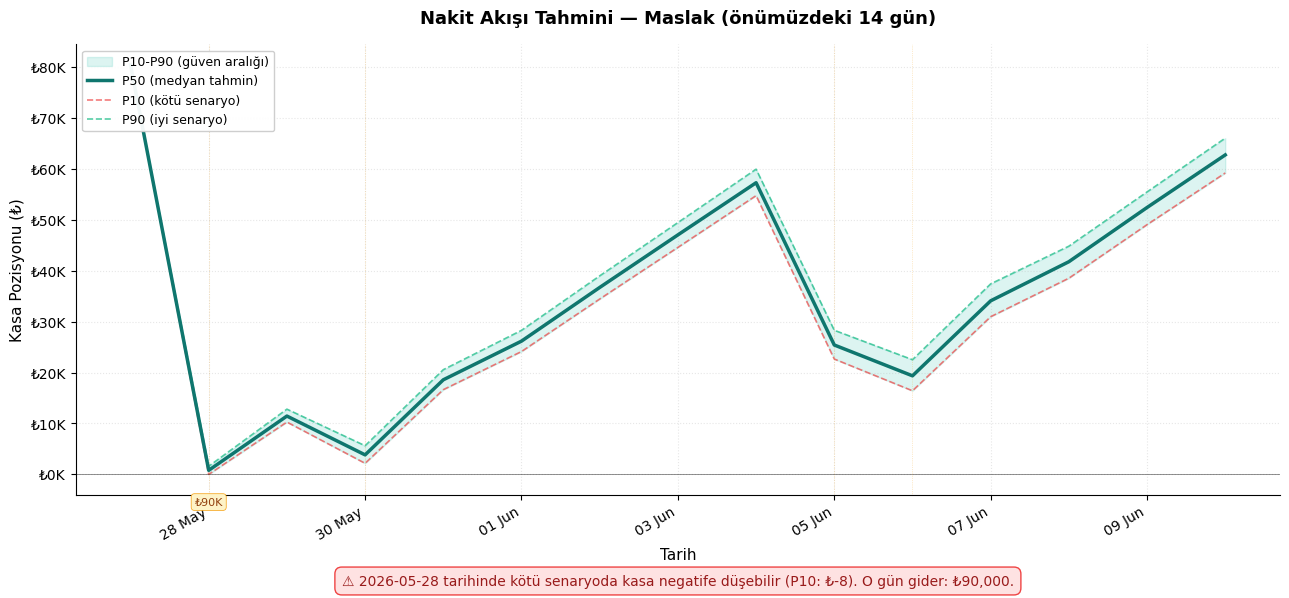

In [40]:
# Maslak — riskli şube
tahmin_maslak = cf.tahmin_et(sube_id=7, gun_sayisi=14)
print("Maslak 14 günlük nakit akışı:")
print(cf.risk_uyarisi(tahmin_maslak))
cf.ciz(sube_id=7, gun_sayisi=14)
plt.show()

## 5. Modül 4 — Finansal Sağlık Skoru

Bankaların kredi skoru mantığını restoran finansına uyarlamak — POS verisinden tek bir 0-100 arası sağlık göstergesi.

**Bileşenler ve ağırlıklar:**

| Bileşen | Ağırlık |
|---|---:|
| Brüt kar marjı | %25 |
| Stok devir hızı | %15 |
| Personel verimi | %15 |
| COGS sapma sağlığı | %15 |
| Ortalama sepet | %10 |
| Büyüme | %10 |
| Atık/Fire | %10 |

**Skor bandları:**

- 80+: Sağlıklı — büyüme yatırımı yapılabilir
- 60-79: İzlenmeli — küçük müdahalelerle düzeltilebilir
- 40-59: Riskli — acil aksiyon gerekli
- 0-39: Kriz — 6 ay içinde kapanma riski

In [41]:
# Kadıköy şubesinin detaylı skor analizi
skor = hs.hesapla(sube_id=1)
print(f"Şube:   {skor['sube_adi']}")
print(f"Skor:   {skor['skor']} → {skor['etiket']}")
print("\nBileşenler:")
for k, v in skor["bilesenler"].items():
    print(f"  {k:25s} {v}")
print("\nHam metrikler:")
for k, v in skor["ham_metrikler"].items():
    print(f"  {k:25s} {v}")

Şube:   Kadıköy Merkez
Skor:   73 → İzlenmeli

Bileşenler:
  brut_kar_marji            100
  stok_devir_hizi           100
  personel_verimi           27.6
  cogs_sapma_sagligi        76.7
  ortalama_sepet            41.7
  yogun_saat                56.7
  atik_fire                 70.6

Ham metrikler:
  gunluk_ort_ciro           36538.17
  brut_marji_yuzde          63.42
  cogs_sapma_yuzde          4.91
  ortalama_sepet            216.85
  buyume_yuzde              -1.67


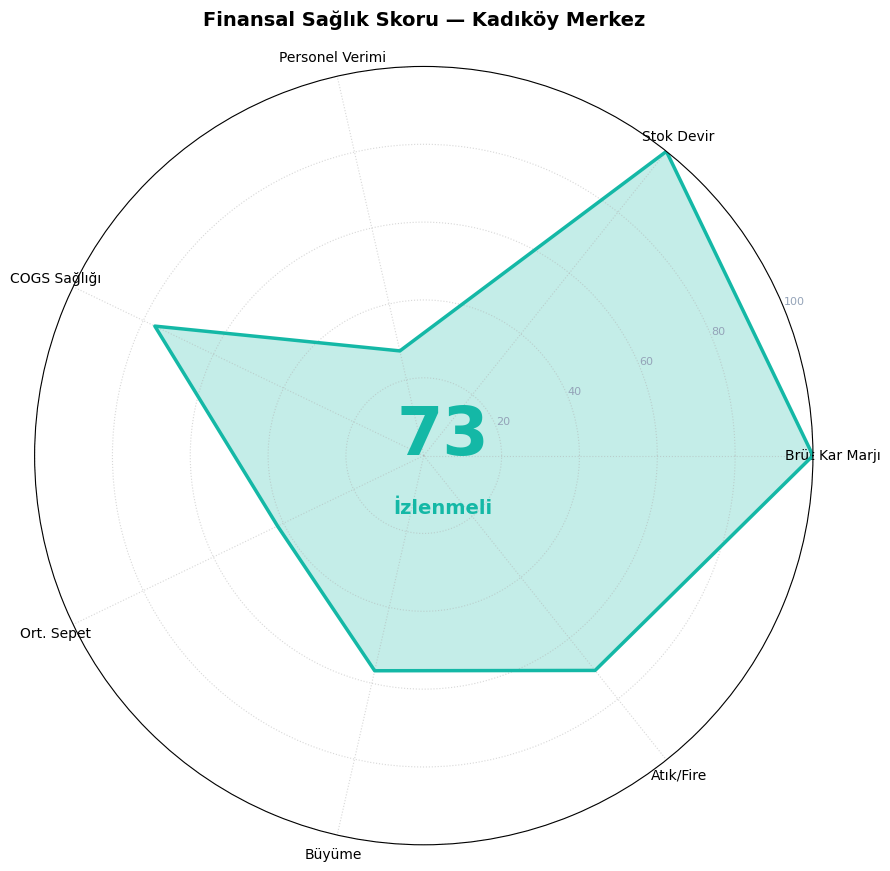

In [42]:
# Radar grafiği — Kadıköy
hs.radar_ciz(sube_id=1)
plt.show()

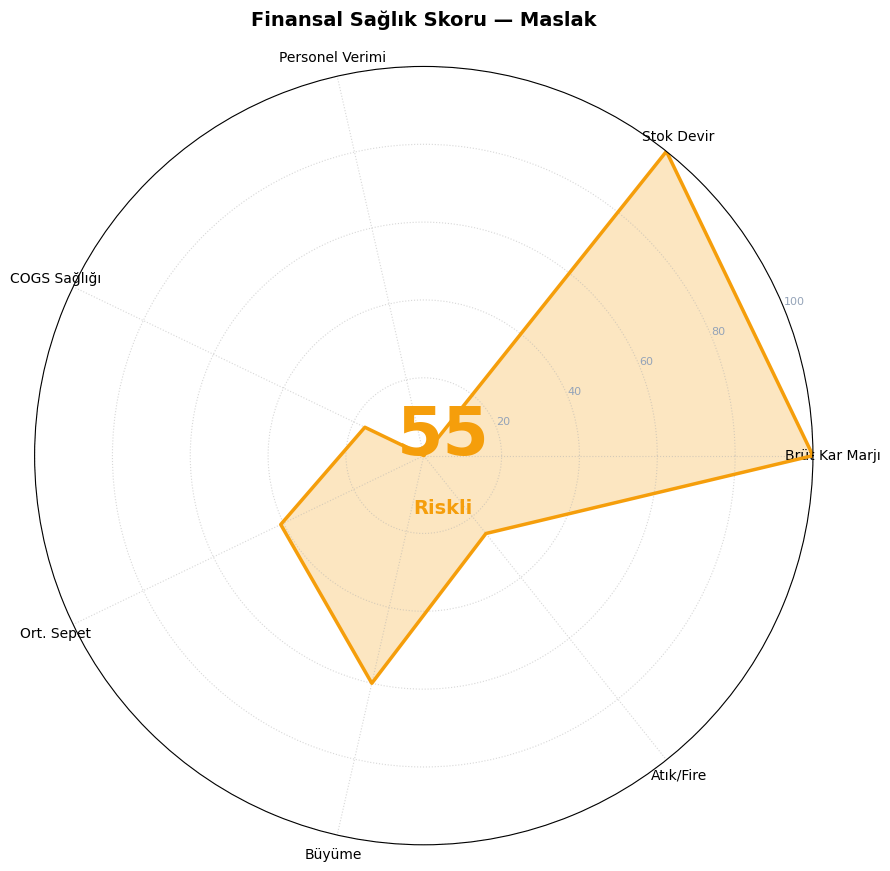

In [43]:
# Kriz seviyesinde bir şube karşılaştırması — Maslak
hs.radar_ciz(sube_id=7)
plt.show()

## 6. Şube Karşılaştırması

Tüm zincir tek bakışta. Bölge müdürünün sabah panoyu açtığında ilk göreceği görüntü.

In [44]:
# Tüm şubelerin skor tablosu
tum = hs.tum_subeler_skor()
tum

,sube,skor,etiket,gunluk_ciro,buyume_yuzde
0,Bağdat Caddesi,86,Sağlıklı,72132.00,-3.55
1,Nişantaşı,86,Sağlıklı,70554.33,0.09
2,Kadıköy Merkez,73,İzlenmeli,36538.17,-1.67
3,Beşiktaş,72,İzlenmeli,42145.00,-1.35
4,Ataşehir,66,İzlenmeli,31329.67,-0.26
5,Bakırköy,58,Riskli,23192.50,-2.10
6,Maslak,55,Riskli,17691.50,-0.02


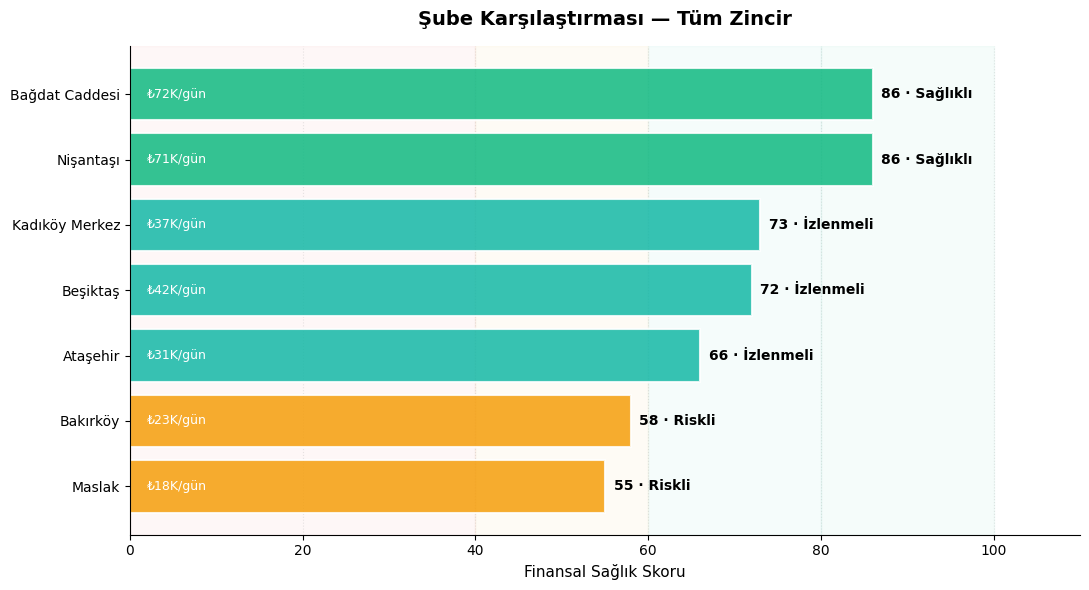

In [45]:
# Yatay bar chart olarak
hs.karsilastirma_ciz()
plt.show()

## Sonuç

Dört modülün hepsi tek bir POS veritabanı üzerinde çalışıyor. Her modül kendi başına anlamlı bir çıktı veriyor, beraber kullanıldıklarında bir restoran zincirinin finansal sağlığının tam resmini sunuyor.

**Sırada ne var?**

- Bu modüller `api/main.py` üzerinden REST endpoint olarak servis ediliyor → `http://localhost:8000/docs`
- `dashboard/index.html` bu API'den veri çekerek görsel sunum yapıyor
- Üretim versiyonunda nakit akışı tahmini için **Prophet**, anomali tespiti için **Isolation Forest** (zaten kullanılıyor) genişletilir, model tuning eklenir.

**Repo yapısı:**

```
kakm/
├── api/         # FastAPI REST servisi
├── analytics/   # bu klasör — Python analitik motor
└── dashboard/   # HTML görsel arayüz
```